In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [8]:
burstgpt = pd.read_csv('../data/processed/burstgpt_full.csv',
                        index_col='timestamp', parse_dates=True)
azure = pd.read_csv('../data/processed/azure_full.csv',
                     index_col='timestamp', parse_dates=True)

print("BurstGPT shape:", burstgpt.shape)
print("Azure shape:", azure.shape)
print("\nBurstGPT stats:\n", burstgpt['rps'].describe())

BurstGPT shape: (174240, 2)
Azure shape: (60, 2)

BurstGPT stats:
 count    174240.000000
mean        294.618916
std         646.381731
min           0.000000
25%           0.000000
50%          20.000000
75%         220.000000
max       10110.000000
Name: rps, dtype: float64


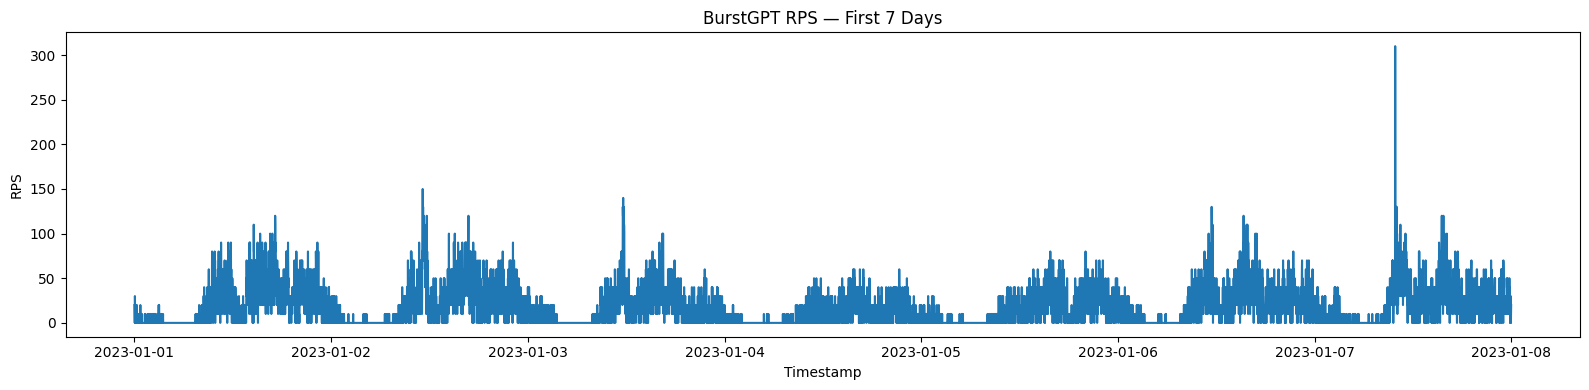

In [9]:
sample = burstgpt['rps'].iloc[:60*24*7]   # first 7 days
plt.figure(figsize=(16, 4))
plt.plot(sample)
plt.title('BurstGPT RPS — First 7 Days')
plt.xlabel('Timestamp')
plt.ylabel('RPS')
plt.tight_layout()
plt.savefig('../results/phase1/figures/burstgpt_7days.png', dpi=150)
plt.show()

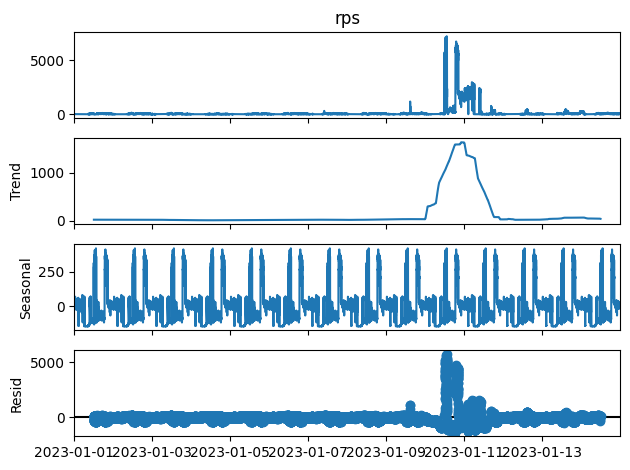

In [10]:
decomp = seasonal_decompose(burstgpt['rps'].iloc[:60*24*14],
                             model='additive', period=60*24)
decomp.plot()
plt.savefig('../results/phase1/figures/burstgpt_decomposition.png', dpi=150)
plt.show()

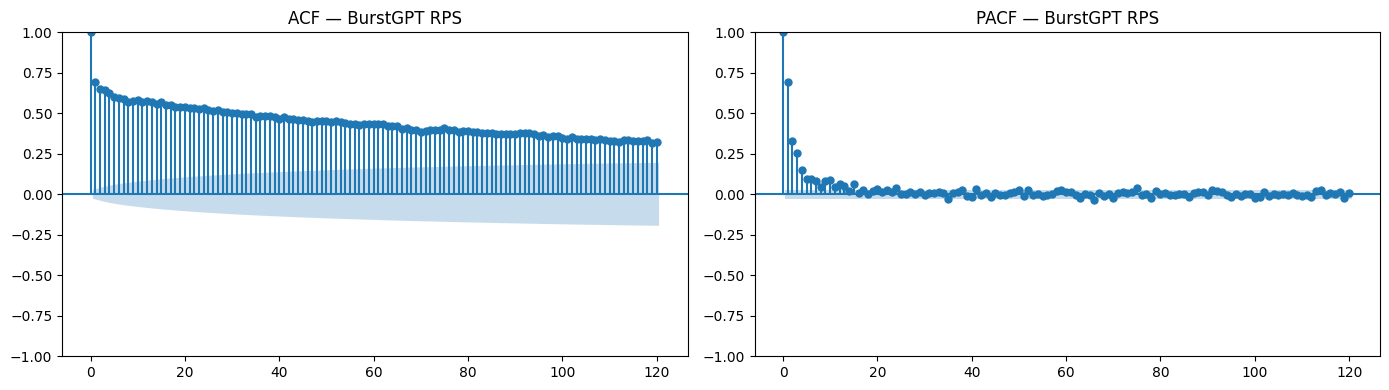

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(burstgpt['rps'].dropna().iloc[:5000], lags=120, ax=axes[0])
plot_pacf(burstgpt['rps'].dropna().iloc[:5000], lags=120, ax=axes[1])
axes[0].set_title('ACF — BurstGPT RPS')
axes[1].set_title('PACF — BurstGPT RPS')
plt.tight_layout()
plt.savefig('../results/phase1/figures/burstgpt_acf_pacf.png', dpi=150)
plt.show()


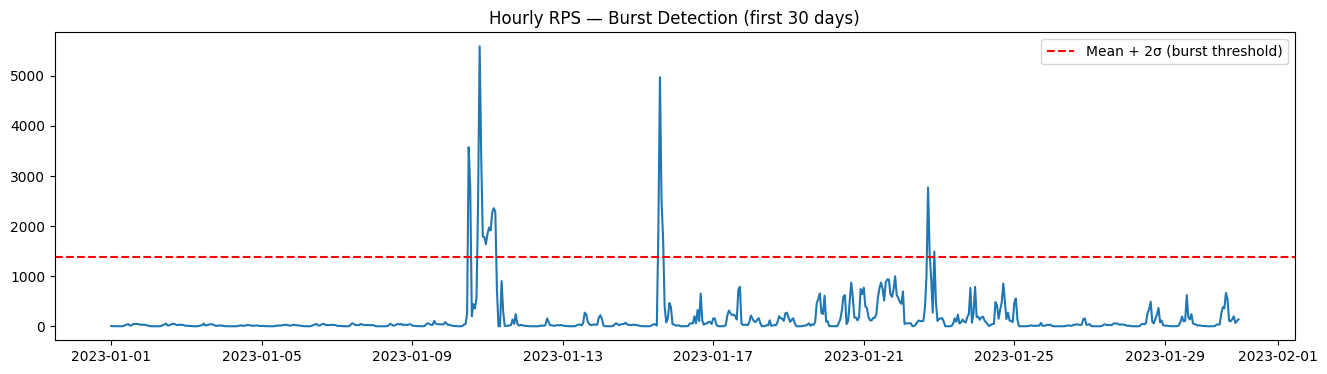

In [12]:
hourly = burstgpt['rps'].resample('1h').mean()
plt.figure(figsize=(16, 4))
plt.plot(hourly.iloc[:24*30])   # first 30 days, hourly
plt.axhline(hourly.mean() + 2*hourly.std(), color='red',
            linestyle='--', label='Mean + 2σ (burst threshold)')
plt.title('Hourly RPS — Burst Detection (first 30 days)')
plt.legend()
plt.savefig('../results/phase1/figures/burstgpt_bursts.png', dpi=150)
plt.show()


In [13]:
print("\n--- Dataset Comparison ---")
for name, df in [('BurstGPT', burstgpt), ('Azure', azure)]:
    r = df['rps']
    print(f"\n{name}:")
    print(f"  Duration : {(r.index[-1] - r.index[0]).days} days")
    print(f"  Mean RPS : {r.mean():.3f}")
    print(f"  Std RPS  : {r.std():.3f}")
    print(f"  Max RPS  : {r.max():.3f}")
    print(f"  Zeros    : {(r == 0).sum()} ({100*(r==0).mean():.1f}%)")


--- Dataset Comparison ---

BurstGPT:
  Duration : 120 days
  Mean RPS : 294.619
  Std RPS  : 646.382
  Max RPS  : 10110.000
  Zeros    : 61636 (35.4%)

Azure:
  Duration : 0 days
  Mean RPS : 329.583
  Std RPS  : 75.075
  Max RPS  : 502.000
  Zeros    : 0 (0.0%)
